### Mushroom (calssification) dataset
Location of dataset: https://www.kaggle.com/datasets/vishalpnaik/mushroom-classification-edible-or-poisonous/data. The goal is to predict whether a mushroom is edible or poisonous. There are 61069 rows in the dataset. Data analysis locates here: Exercise_project_1\Classification_dataset\dataset_analysis_code.ipynb
Target variable is Class (binary, classification).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

from sklearn.preprocessing import OneHotEncoder, LabelEncoder

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score

In [2]:
# load the data
df = pd.read_csv('mushroom.csv')

df.head()

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


### Cleaning dataset

In [3]:
df.columns.tolist()

['class',
 'cap-diameter',
 'cap-shape',
 'cap-surface',
 'cap-color',
 'does-bruise-or-bleed',
 'gill-attachment',
 'gill-spacing',
 'gill-color',
 'stem-height',
 'stem-width',
 'stem-root',
 'stem-surface',
 'stem-color',
 'veil-type',
 'veil-color',
 'has-ring',
 'ring-type',
 'spore-print-color',
 'habitat',
 'season']

In [4]:
df.isnull().sum()

class                       0
cap-diameter                0
cap-shape                   0
cap-surface             14120
cap-color                   0
does-bruise-or-bleed        0
gill-attachment          9884
gill-spacing            25063
gill-color                  0
stem-height                 0
stem-width                  0
stem-root               51538
stem-surface            38124
stem-color                  0
veil-type               57892
veil-color              53656
has-ring                    0
ring-type                2471
spore-print-color       54715
habitat                     0
season                      0
dtype: int64

In [5]:
cols = df.columns.tolist()
for col in cols:
    unique_name = df[col].unique()
    print(f'{col} has {unique_name}')

class has ['p' 'e']
cap-diameter has [15.26 16.6  14.07 ... 22.85 21.8  20.42]
cap-shape has ['x' 'f' 'p' 'b' 'c' 's' 'o']
cap-surface has ['g' 'h' nan 't' 'y' 'e' 's' 'l' 'd' 'w' 'i' 'k']
cap-color has ['o' 'e' 'n' 'g' 'r' 'w' 'y' 'p' 'u' 'b' 'l' 'k']
does-bruise-or-bleed has ['f' 't']
gill-attachment has ['e' nan 'a' 'd' 's' 'x' 'p' 'f']
gill-spacing has [nan 'c' 'd' 'f']
gill-color has ['w' 'n' 'p' 'u' 'b' 'g' 'y' 'r' 'e' 'o' 'k' 'f']
stem-height has [16.95 17.99 17.8  ...  1.23  1.16  0.  ]
stem-width has [17.09 18.19 17.74 ... 32.59 30.99 30.51]
stem-root has ['s' nan 'b' 'r' 'c' 'f']
stem-surface has ['y' nan 's' 'k' 'i' 'h' 't' 'g' 'f']
stem-color has ['w' 'y' 'n' 'u' 'b' 'l' 'r' 'p' 'e' 'k' 'g' 'o' 'f']
veil-type has ['u' nan]
veil-color has ['w' 'y' nan 'n' 'e' 'u' 'k']
has-ring has ['t' 'f']
ring-type has ['g' 'p' 'e' 'l' 'f' 'm' nan 'r' 'z']
spore-print-color has [nan 'w' 'p' 'k' 'r' 'u' 'n' 'g']
habitat has ['d' 'm' 'g' 'h' 'l' 'p' 'w' 'u']
season has ['w' 'u' 'a' 's']


In [6]:
# List of columns to drop
cols_to_drop = ['stem-root', 'spore-print-color', 'veil-color',"veil-type",'stem-surface']

# Drop them from the dataset
df = df.drop(columns=cols_to_drop)

In [7]:
# Check number of duplicates
print("Duplicates found:", df.duplicated().sum())

# View some duplicate rows
df[df.duplicated()].head()

Duplicates found: 146


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
9863,p,1.14,x,g,w,f,a,d,w,3.13,1.78,e,f,f,d,u
12978,p,0.72,x,g,y,f,NaN,NaN,y,3.51,0.77,y,f,f,d,u
56526,p,4.27,o,s,n,f,NaN,c,w,0.00,0.00,f,f,f,d,u
56533,p,4.29,o,t,w,f,NaN,c,w,0.00,0.00,f,f,f,d,u
56576,p,4.59,o,s,w,f,NaN,c,w,0.00,0.00,f,f,f,d,u


In [8]:
# Code to fill missing values with "missing"
# List of target columns
cols_to_fill = ['cap-surface', 'gill-attachment', 'gill-spacing', 'ring-type']
df[cols_to_fill] = df[cols_to_fill].fillna('unknown')

In [9]:
df.isnull().sum()

class                   0
cap-diameter            0
cap-shape               0
cap-surface             0
cap-color               0
does-bruise-or-bleed    0
gill-attachment         0
gill-spacing            0
gill-color              0
stem-height             0
stem-width              0
stem-color              0
has-ring                0
ring-type               0
habitat                 0
season                  0
dtype: int64

In [10]:
cols = df.columns.tolist()

for col in cols:
    unique_count = df[col].nunique()
    print(f'{col} has {unique_count} unique values')

class has 2 unique values
cap-diameter has 2571 unique values
cap-shape has 7 unique values
cap-surface has 12 unique values
cap-color has 12 unique values
does-bruise-or-bleed has 2 unique values
gill-attachment has 8 unique values
gill-spacing has 4 unique values
gill-color has 12 unique values
stem-height has 2226 unique values
stem-width has 4630 unique values
stem-color has 13 unique values
has-ring has 2 unique values
ring-type has 9 unique values
habitat has 8 unique values
season has 4 unique values


In [11]:
# here I will encode the categorical variables using one-hot encoding
# Copy the dataset
df_encoded = df.copy()

# Columns to encode
numeric_features = ['cap-diameter', 'stem-height', 'stem-width']
binary_categorical = ["class",'does-bruise-or-bleed', 'has-ring']
onehot_categorical = ['cap-shape', 'cap-surface', 'cap-color', 'gill-attachment',
                      'gill-spacing', 'gill-color', 'stem-color', 'ring-type',
                      'habitat', 'season']

In [12]:
from sklearn.preprocessing import OneHotEncoder

variables_oneHot_cat = onehot_categorical

# use encoder:
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df_encoded[variables_oneHot_cat]).astype(int)


df_encoded = pd.concat([df_encoded,one_hot_encoded],axis=1).drop(columns=variables_oneHot_cat)

In [13]:
from sklearn.preprocessing import LabelEncoder

# list of all boolean variables we want to convert
variables_label_Encode = binary_categorical

# initalize encoder and convert everything
encoder = LabelEncoder()
df_encoded[variables_label_Encode] = df_encoded[variables_label_Encode].apply(encoder.fit_transform)

In [14]:
cols = df_encoded.columns.tolist()
print(cols)

['class', 'cap-diameter', 'does-bruise-or-bleed', 'stem-height', 'stem-width', 'has-ring', 'cap-shape_b', 'cap-shape_c', 'cap-shape_f', 'cap-shape_o', 'cap-shape_p', 'cap-shape_s', 'cap-shape_x', 'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h', 'cap-surface_i', 'cap-surface_k', 'cap-surface_l', 'cap-surface_s', 'cap-surface_t', 'cap-surface_unknown', 'cap-surface_w', 'cap-surface_y', 'cap-color_b', 'cap-color_e', 'cap-color_g', 'cap-color_k', 'cap-color_l', 'cap-color_n', 'cap-color_o', 'cap-color_p', 'cap-color_r', 'cap-color_u', 'cap-color_w', 'cap-color_y', 'gill-attachment_a', 'gill-attachment_d', 'gill-attachment_e', 'gill-attachment_f', 'gill-attachment_p', 'gill-attachment_s', 'gill-attachment_unknown', 'gill-attachment_x', 'gill-spacing_c', 'gill-spacing_d', 'gill-spacing_f', 'gill-spacing_unknown', 'gill-color_b', 'gill-color_e', 'gill-color_f', 'gill-color_g', 'gill-color_k', 'gill-color_n', 'gill-color_o', 'gill-color_p', 'gill-color_r', 'gill-color_u', 'g

In [15]:
cols = df_encoded.columns.tolist()

for col in cols:
    unique_count = df_encoded[col].nunique()
    print(f'{col} has {unique_count} unique values')

class has 2 unique values
cap-diameter has 2571 unique values
does-bruise-or-bleed has 2 unique values
stem-height has 2226 unique values
stem-width has 4630 unique values
has-ring has 2 unique values
cap-shape_b has 2 unique values
cap-shape_c has 2 unique values
cap-shape_f has 2 unique values
cap-shape_o has 2 unique values
cap-shape_p has 2 unique values
cap-shape_s has 2 unique values
cap-shape_x has 2 unique values
cap-surface_d has 2 unique values
cap-surface_e has 2 unique values
cap-surface_g has 2 unique values
cap-surface_h has 2 unique values
cap-surface_i has 2 unique values
cap-surface_k has 2 unique values
cap-surface_l has 2 unique values
cap-surface_s has 2 unique values
cap-surface_t has 2 unique values
cap-surface_unknown has 2 unique values
cap-surface_w has 2 unique values
cap-surface_y has 2 unique values
cap-color_b has 2 unique values
cap-color_e has 2 unique values
cap-color_g has 2 unique values
cap-color_k has 2 unique values
cap-color_l has 2 unique values
c

In [16]:
df_encoded.to_csv("mushroom_encoded.csv", index=False)

In [17]:
# we have too many variable. 
# I will keep variable that contribute the most to the model and drop the rest. 
# I will check that using SHAP tool:
# remove special characters
df_encoded.columns = (
    df_encoded.columns
    .str.replace('<', '', regex=False)
    .str.replace('>', '', regex=False)
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace(' ', '_', regex=False)
)

In [18]:
df_encoded.columns

Index(['class', 'cap-diameter', 'does-bruise-or-bleed', 'stem-height',
       'stem-width', 'has-ring', 'cap-shape_b', 'cap-shape_c', 'cap-shape_f',
       'cap-shape_o', 'cap-shape_p', 'cap-shape_s', 'cap-shape_x',
       'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h',
       'cap-surface_i', 'cap-surface_k', 'cap-surface_l', 'cap-surface_s',
       'cap-surface_t', 'cap-surface_unknown', 'cap-surface_w',
       'cap-surface_y', 'cap-color_b', 'cap-color_e', 'cap-color_g',
       'cap-color_k', 'cap-color_l', 'cap-color_n', 'cap-color_o',
       'cap-color_p', 'cap-color_r', 'cap-color_u', 'cap-color_w',
       'cap-color_y', 'gill-attachment_a', 'gill-attachment_d',
       'gill-attachment_e', 'gill-attachment_f', 'gill-attachment_p',
       'gill-attachment_s', 'gill-attachment_unknown', 'gill-attachment_x',
       'gill-spacing_c', 'gill-spacing_d', 'gill-spacing_f',
       'gill-spacing_unknown', 'gill-color_b', 'gill-color_e', 'gill-color_f',
       'gill-colo

c:\Storage\Studies\Lapland_AMK\5_semester\Deep_learning\.venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The most Important Features:
                 Feature  Importance
0           cap-diameter    0.014478
1   does-bruise-or-bleed    0.018129
2            stem-height    0.034098
3             stem-width    0.126578
4               has-ring    0.014205
..                   ...         ...
89             habitat_w    0.000000
90              season_a    0.000076
91              season_s    0.001103
92              season_u    0.000070
93              season_w    0.000275

[94 rows x 2 columns]


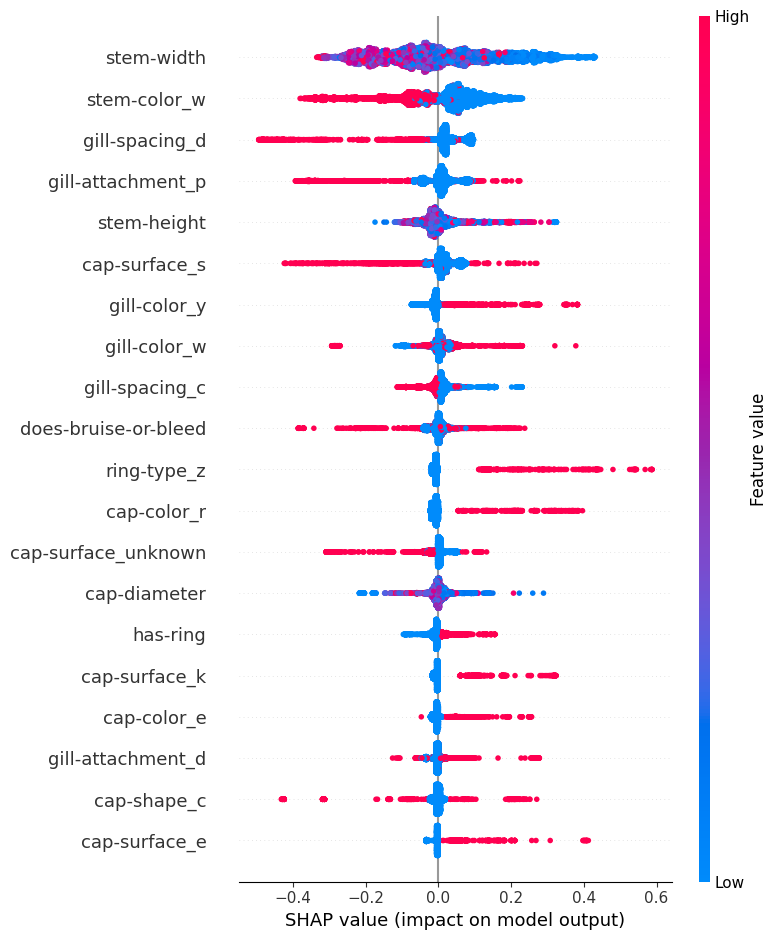

In [19]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

# Define features and target
X = df_encoded[[ 'cap-diameter', 'does-bruise-or-bleed', 'stem-height',
       'stem-width', 'has-ring', 'cap-shape_b', 'cap-shape_c', 'cap-shape_f',
       'cap-shape_o', 'cap-shape_p', 'cap-shape_s', 'cap-shape_x',
       'cap-surface_d', 'cap-surface_e', 'cap-surface_g', 'cap-surface_h',
       'cap-surface_i', 'cap-surface_k', 'cap-surface_l', 'cap-surface_s',
       'cap-surface_t', 'cap-surface_unknown', 'cap-surface_w',
       'cap-surface_y', 'cap-color_b', 'cap-color_e', 'cap-color_g',
       'cap-color_k', 'cap-color_l', 'cap-color_n', 'cap-color_o',
       'cap-color_p', 'cap-color_r', 'cap-color_u', 'cap-color_w',
       'cap-color_y', 'gill-attachment_a', 'gill-attachment_d',
       'gill-attachment_e', 'gill-attachment_f', 'gill-attachment_p',
       'gill-attachment_s', 'gill-attachment_unknown', 'gill-attachment_x',
       'gill-spacing_c', 'gill-spacing_d', 'gill-spacing_f',
       'gill-spacing_unknown', 'gill-color_b', 'gill-color_e', 'gill-color_f',
       'gill-color_g', 'gill-color_k', 'gill-color_n', 'gill-color_o',
       'gill-color_p', 'gill-color_r', 'gill-color_u', 'gill-color_w',
       'gill-color_y', 'stem-color_b', 'stem-color_e', 'stem-color_f',
       'stem-color_g', 'stem-color_k', 'stem-color_l', 'stem-color_n',
       'stem-color_o', 'stem-color_p', 'stem-color_r', 'stem-color_u',
       'stem-color_w', 'stem-color_y', 'ring-type_e', 'ring-type_f',
       'ring-type_g', 'ring-type_l', 'ring-type_m', 'ring-type_p',
       'ring-type_r', 'ring-type_unknown', 'ring-type_z', 'habitat_d',
       'habitat_g', 'habitat_h', 'habitat_l', 'habitat_m', 'habitat_p',
       'habitat_u', 'habitat_w', 'season_a', 'season_s', 'season_u',
       'season_w']]

y = df_encoded['class']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Train model
model = RandomForestRegressor()
model.fit(X_train, y_train)

# Initialize SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot SHAP summary
shap.summary_plot(shap_values, X_test, show=False)

# Feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': np.mean(np.abs(shap_values), axis=0)
})

# Sort and display top 10 features
top5 = importance.sort_values(by="Importance", ascending=False).head(5)

print("The most Important Features:")
print(importance)

In [20]:
print(top5)

              Feature  Importance
3          stem-width    0.126578
71       stem-color_w    0.086774
45     gill-spacing_d    0.052713
40  gill-attachment_p    0.040537
2         stem-height    0.034098


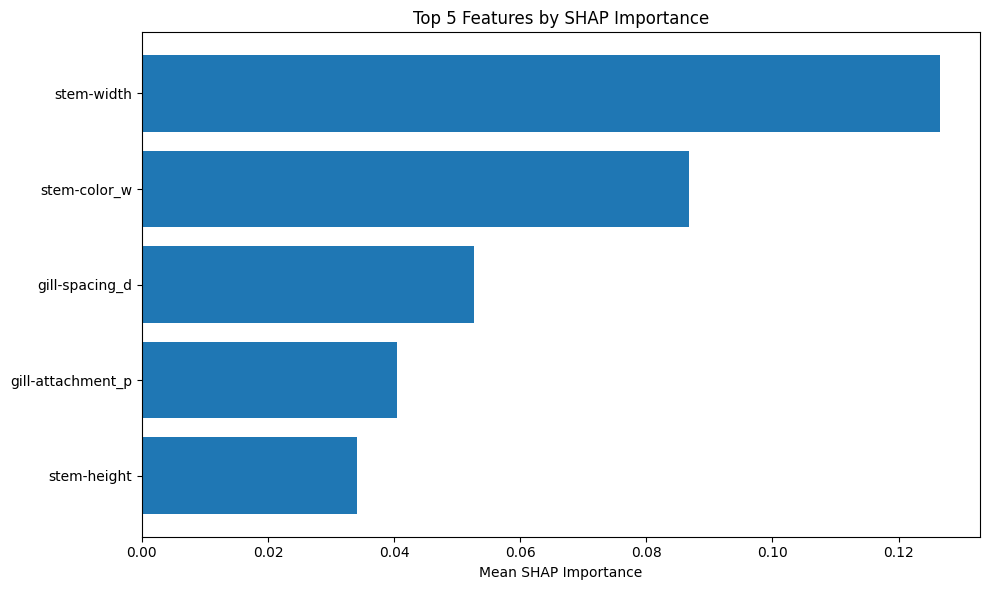

In [21]:
import matplotlib.pyplot as plt

# Plot top 10 features
top5 = importance.sort_values(by="Importance", ascending=False).head(5)
plt.figure(figsize=(10, 6))
plt.barh(top5['Feature'][::-1], top5['Importance'][::-1])
plt.xlabel("Mean SHAP Importance")
plt.title("Top 5 Features by SHAP Importance")
plt.tight_layout()
plt.show()

In [ ]:
# Keep only the top 5 most important features and drop the rest
top5_features = top5['Feature'].tolist()
print("Top 5 Features to Keep:")
print(top5_features)

# Create a new dataframe with only the top 5 features and the target variable
mush_reduced_df = df_encoded[top5_features + ['class']]


Top 5 Features to Keep:
['stem-width', 'stem-color_w', 'gill-spacing_d', 'gill-attachment_p', 'stem-height']
New dataframe with top 5 features and target:
   stem-width  stem-color_w  gill-spacing_d  gill-attachment_p  stem-height  \
0       17.09             1               0                  0        16.95   
1       18.19             1               0                  0        17.99   
2       17.74             1               0                  0        17.80   
3       15.98             1               0                  0        15.77   
4       17.20             1               0                  0        16.53   

   class  
0      1  
1      1  
2      1  
3      1  
4      1  


In [24]:
mush_reduced_df.head()

,stem-width,stem-color_w,gill-spacing_d,gill-attachment_p,stem-height,class
0,17.09,1,0,0,16.95,1
1,18.19,1,0,0,17.99,1
2,17.74,1,0,0,17.80,1
3,15.98,1,0,0,15.77,1
4,17.20,1,0,0,16.53,1


In [25]:
# I will save it to a new csv file for later use in the ANN model.
mush_reduced_df.to_csv("mushroom_reduced.csv", index=False)
